<a href="https://colab.research.google.com/github/pparbhat223-ai/Section3_Python_Data_Processing/blob/main/NorthStar_Section3_Python_Data_Processing_Operational_Intelligence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

# Step 2 – Load  Data

In [ ]:
customers = pd.read_csv("customers.csv")

orders = pd.read_csv("orders.csv")

drivers = pd.read_csv("drivers.csv")

vehicles = pd.read_csv("vehicles.csv")

complaints = pd.read_csv("complaints.csv")

app_events = pd.read_csv("app_events.csv")

incidents = pd.read_csv("incidents.csv")

hubs = pd.read_csv("hubs.csv")

print("datasets loaded")

datasets loaded


# Step 3 – Create Integrated Master Dataset

Combining datasets to simulate unified data platform required by NorthStar.

In [ ]:
master_data = orders.merge(customers, on="customer_id", how="left")

master_data = master_data.merge(
complaints,
on="order_id",
how="left"
)

master_data["complaint_flag"] = np.where(
master_data["complaint_id"].isna(),
0,
1
)

master_data.head()

,order_id,customer_id_x,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status,complaint_id,customer_id_y,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount,complaint_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0,24,South,Consumer,2025-03-02 11:24:00,73.2,57.9,App,Active,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0,20,WEST,Consumer,2024-09-23 21:00:00,56.1,62.6,App,Dormant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0,42,north,Consumer,2024-06-07 22:41:00,87.1,36.6,App,Active,CP0165,C0161,AppIssue,Phone,Medium,2025-09-07 14:37:00,Open,2.0,8.66,1
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1,50,NORTH,Consumer,2025-04-21 07:28:00,53.6,80.4,Partner API,Active,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0,23,SOUTH,Consumer,2024-06-29 19:47:00,64.3,38.5,Phone,Active,CP0120,C0558,MissedPickup,Phone,Medium,2025-02-25 19:32:00,Resolved,8.0,54.41,1


# ANALYSIS 1
Demand pressure across zones

Identify areas with operational overload.

In [ ]:
zone_demand = orders.groupby("pickup_zone").agg(

total_orders=("order_id","count"),

avg_order_value=("order_value","mean")

).reset_index()

zone_demand = zone_demand.sort_values(
"total_orders",
ascending=False
)

zone_demand

,pickup_zone,total_orders,avg_order_value
6,East,104,92.216827
5,EAST,103,91.327573
12,South,103,92.402524
9,RiverSide,86,80.379884
1,Airport,85,108.852000
13,WEST,84,89.197976
4,Ctr,80,94.499875
2,CENTRAL,79,93.575570
3,Central,79,77.200506
11,SOUTH,78,88.184872


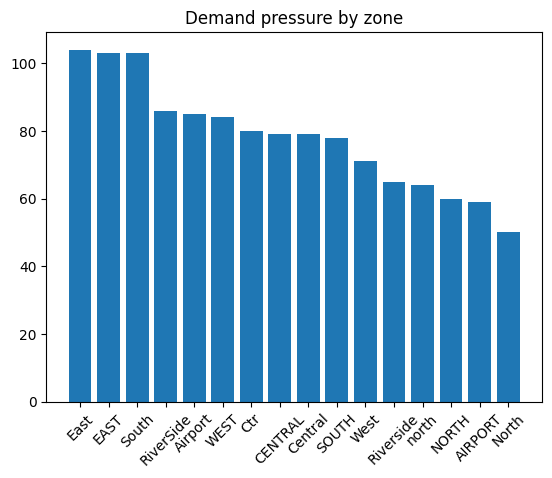

In [ ]:
plt.figure()

plt.bar(
zone_demand["pickup_zone"],
zone_demand["total_orders"]
)

plt.title("Demand pressure by zone")

plt.xticks(rotation=45)

plt.show()

Business insight:
Shows geographical imbalance affecting dispatch efficiency.

# ANALYSIS 2
# Customer dissatisfaction drivers

Identify operational causes of complaints.

In [ ]:
complaint_analysis = master_data.groupby("service_type").agg(

complaint_rate=("complaint_flag","mean"),

avg_value=("order_value","mean")

).reset_index()

complaint_analysis

,service_type,complaint_rate,avg_value
0,Business,0.229412,92.961235
1,Medical,0.258741,86.656294
2,Parcel,0.243671,88.571962
3,Passenger,0.241379,95.359425
4,Retail,0.269481,90.038701


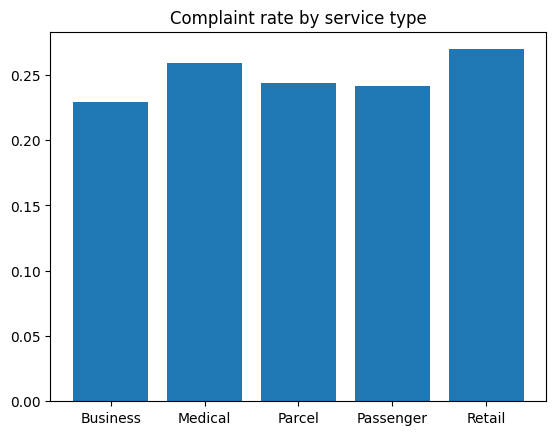

In [ ]:
plt.figure()

plt.bar(
complaint_analysis["service_type"],
complaint_analysis["complaint_rate"]
)

plt.title("Complaint rate by service type")

plt.show()

Insight:
High complaint rates indicate unreliable service segments.

# ANALYSIS 3
# Customer behaviour segmentation

Identify engagement-based customer groups.

In [ ]:
customer_segments = customers.copy()

customer_segments["engagement_level"] = np.where(

customer_segments["app_engagement_score"]>70,
"high",

np.where(
customer_segments["app_engagement_score"]>40,
"medium",
"low"
)

)

customer_segments.groupby(
"engagement_level"
).size()

,0
engagement_level,
high,183
low,117
medium,350


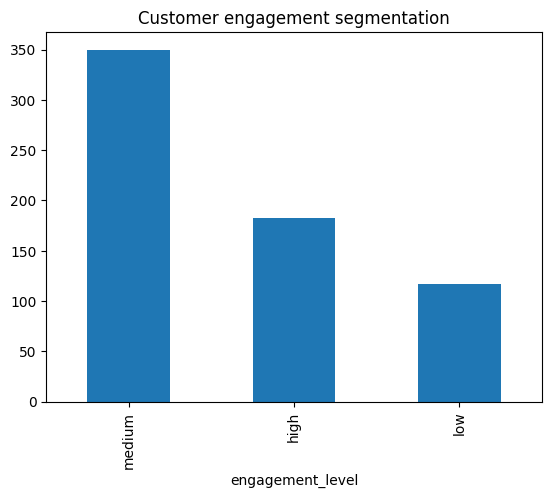

In [ ]:
plt.figure()

customer_segments["engagement_level"].value_counts().plot(
kind="bar"
)

plt.title("Customer engagement segmentation")

plt.show()

Insight:
Low engagement customers may struggle with app usability.

# ANALYSIS 4
# Driver capability index

Evaluate workforce performance consistency.

In [ ]:
drivers["performance_index"] = (

drivers["driver_rating"]*0.6 +

drivers["training_score"]*0.4

)

driver_performance = drivers.groupby("base_zone").agg(

avg_performance=("performance_index","mean"),

avg_experience=("years_experience","mean")

).reset_index()

driver_performance

,base_zone,avg_performance,avg_experience
0,AIRPORT,34.768600,9.500000
1,Airport,34.930250,9.000000
2,CENTRAL,27.506400,8.100000
3,Central,31.500182,9.833333
4,Ctr,27.953667,5.000000
5,EAST,34.067333,6.571429
6,East,33.197231,9.000000
7,NORTH,33.746500,6.500000
8,North,34.215538,8.692308
9,RiverSide,31.874222,6.800000


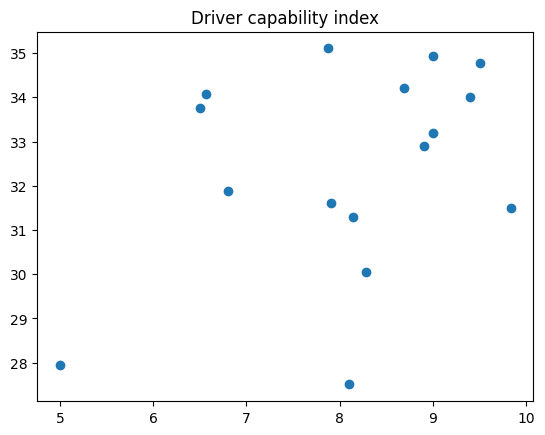

In [ ]:
plt.figure()

plt.scatter(

driver_performance["avg_experience"],

driver_performance["avg_performance"]

)

plt.title("Driver capability index")

plt.show()

Insight:
Identifies zones requiring training improvements.

# ANALYSIS 5
# Fleet operational risk score

Detect vehicles likely to cause delays.

In [ ]:
vehicles["risk_score"] = (

100-vehicles["battery_health_pct"].fillna(50)

)+(

vehicles["odometer_km"]/10000

)

fleet_risk = vehicles.sort_values(
"risk_score",
ascending=False
)

fleet_risk.head()

,vehicle_id,vehicle_type,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version,risk_score
72,V073,Hybrid,AIRPORT,2024-05-28 05:33:00,NaN,191353,Active,v2.1,69.1353
104,V105,EV,Ctr,2025-02-16 20:04:00,NaN,149291,Active,v2.1,64.9291
24,V025,Diesel,AIRPORT,2024-11-03 05:34:00,42.0,52074,Active,v2.1,63.2074
28,V029,EV,north,2024-12-04 10:53:00,NaN,130270,Active,v2.0,63.0270
9,V010,CargoVan,NORTH,2025-10-07 22:40:00,50.7,129032,InRepair,v2.1,62.2032


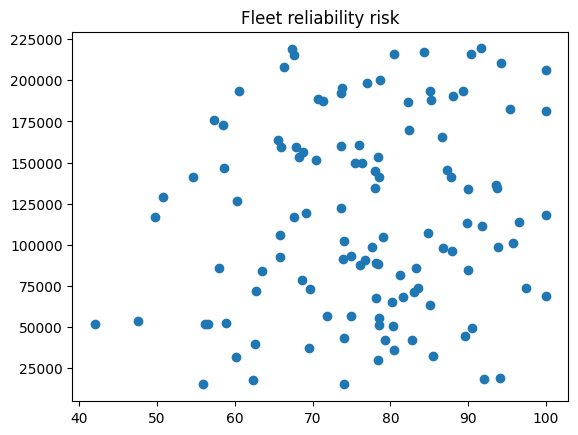

In [ ]:
plt.figure()

plt.scatter(

vehicles["battery_health_pct"],

vehicles["odometer_km"]

)

plt.title("Fleet reliability risk")

plt.show()

Insight:
Low battery health + high mileage increases downtime probability.

# ANALYSIS 6
# App performance bottleneck analysis

Evaluate platform responsiveness.

In [ ]:
app_perf = app_events.groupby("event_type").agg(

avg_latency=("api_latency_ms","mean"),

event_count=("event_id","count")

).reset_index()

app_perf = app_perf.sort_values(
"avg_latency",
ascending=False
)

app_perf

,event_type,avg_latency,event_count
3,delivery_instruction_update,496.293333,75
2,chat_opened,478.329545,88
1,chat_escalated,478.131579,38
5,payment_retry,472.681159,69
7,track_order,460.710145,138
6,search_route,456.505051,99
4,eta_refresh,452.152381,105
0,cancel_attempt,417.142857,28


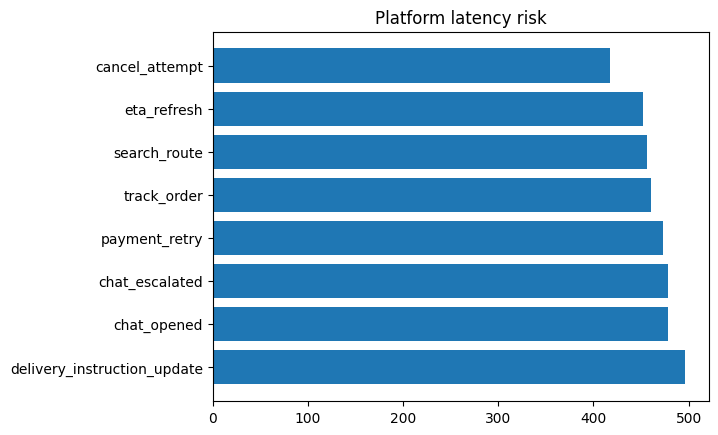

In [ ]:
plt.figure()

plt.barh(

app_perf["event_type"],

app_perf["avg_latency"]

)

plt.title("Platform latency risk")

plt.show()

Insight:
Slow app features affect service experience.

# ANALYSIS 7
# Incident operational severity impact

Identify disruption risk.

In [ ]:
incident_severity = incidents.groupby("incident_type").agg(

avg_resolution=("resolved_hours","mean"),

incident_volume=("incident_id","count")

).reset_index()

incident_severity

,incident_type,avg_resolution,incident_volume
0,AppSyncError,12.657143,31
1,BatteryAlert,11.708824,36
2,CustomerNoShow,13.888095,44
3,ProofMissing,10.767500,46
4,RouteDeviation,13.726829,43
5,SafetyNearMiss,9.669231,14
6,TemperatureIssue,12.917241,29
7,VehicleFault,9.150000,37


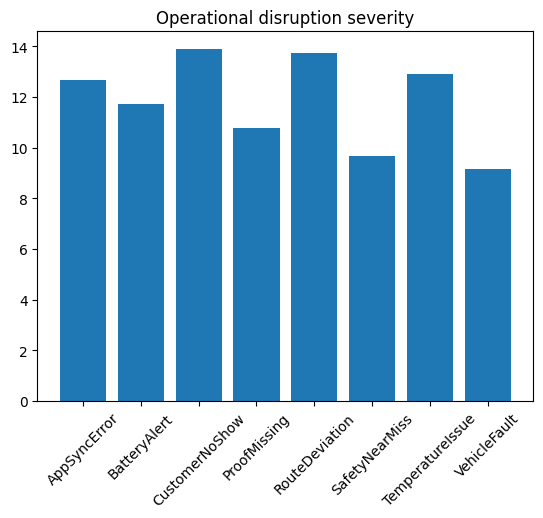

In [ ]:
plt.figure()

plt.bar(

incident_severity["incident_type"],

incident_severity["avg_resolution"]

)

plt.title("Operational disruption severity")

plt.xticks(rotation=45)

plt.show()

Insight:
Longer resolution time increases delivery delays.

# ANALYSIS 8
# Hub efficiency index

Compare infrastructure capacity vs demand.

In [ ]:
hub_demand = zone_demand.merge(

hubs,

left_on="pickup_zone",

right_on="zone",

how="left"

)

hub_demand["efficiency_score"] = (

hub_demand["capacity_score"]

-

hub_demand["total_orders"]

)

hub_demand

,pickup_zone,total_orders,avg_order_value,hub_id,hub_name,zone,hub_type,capacity_score,efficiency_score
0,East,104,92.216827,H03,East Dock,East,Warehouse,74.0,-30.0
1,EAST,103,91.327573,NaN,NaN,NaN,NaN,NaN,NaN
2,South,103,92.402524,H02,South Link,South,Dispatch,78.0,-25.0
3,RiverSide,86,80.379884,NaN,NaN,NaN,NaN,NaN,NaN
4,Airport,85,108.852000,H06,Airport Hub,Airport,Dispatch,71.0,-14.0
5,WEST,84,89.197976,NaN,NaN,NaN,NaN,NaN,NaN
6,Ctr,80,94.499875,NaN,NaN,NaN,NaN,NaN,NaN
7,CENTRAL,79,93.575570,NaN,NaN,NaN,NaN,NaN,NaN
8,Central,79,77.200506,H05,Central Core,Central,Control,88.0,9.0
9,Central,79,77.200506,H08,Midtown Relay,Central,Charging,63.0,-16.0


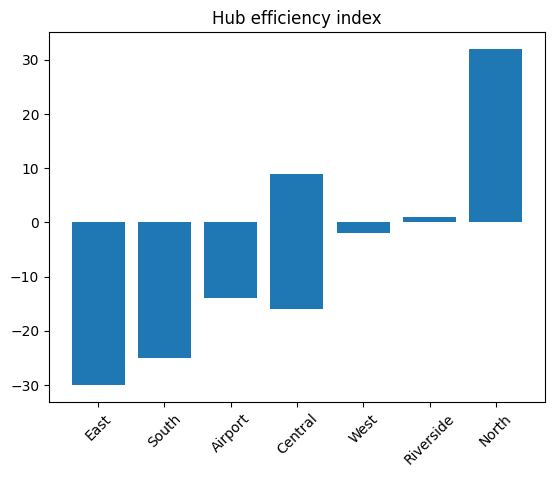

In [ ]:
plt.figure()

hub_demand_clean = hub_demand.dropna(subset=["zone"])

plt.bar(

hub_demand_clean["zone"],

hub_demand_clean["efficiency_score"]

)

plt.title("Hub efficiency index")

plt.xticks(rotation=45)

plt.show()

Insight:
Negative values indicate overloaded hubs.